# 🛰️ LAB: MODELADO GEOGRÁFICO Y CLASIFICACIÓN TEMÁTICA DEL TERRITORIO
**Cuaderno Técnico de Desafíos Avanzados: `practica_geografia.ipynb`**

¡Bienvenidos, geógrafos, analistas GIS y especialistas del territorio! El objetivo de este laboratorio práctico es aplicar redes neuronales artificiales para resolver problemas de modelado ambiental y automatizar la zonificación de coberturas terrestres a partir de datos geoespaciales multi-fuente.

En la geografía moderna y el análisis espacial, los fenómenos naturales no responden a patrones lineales simples. Factores como el relieve interrumpe la temperatura de forma abrupta o la expansión urbana fragmenta los ecosistemas siguiendo dinámicas complejas. A lo largo de este cuaderno, utilizaremos **TensorFlow y Keras** para entrenar una red profunda que aprenda el gradiente térmico vertical real (microclimas) sobre un Modelo Digital de Elevación (DEM), y construiremos un clasificador multiclase capaz de categorizar el uso del suelo basándose en la accesibilidad vial y la densidad de infraestructura.

---

### 🧱 NUESTRA HOJA DE RUTA DE INGENIERÍA

Para resolver con éxito cada uno de los desafíos planteados, deberás aplicar rigurosamente la secuencia de desarrollo estandarizada:

1. **FASE 0 (Canal de Datos):** Cargar e inspeccionar estadísticamente las muestras del territorio simuladas por el instructor, analizando sus distribuciones geográficas.
2. **ETAPA A (Definición Arquitectónica):** Instanciar el modelo secuencial de la red, seleccionando con criterio la cantidad de capas, neuronas y funciones de activación según la complejidad del paisaje.
3. **ETAPA B (Compilación Matemática):** Configurar el optimizador (`Adam`), calibrar el learning rate y definir la función de pérdida matemática idónea (`mse` o `categorical_crossentropy`).
4. **ETAPA C (Entrenamiento Dinámico):** Ejecutar el ciclo de aprendizaje (`fit`) cruzando el entrenamiento con el conjunto de validación del territorio.
5. **EVALUACIÓN ANALÍTICA:** Auditar geográficamente los resultados y contrastar las fronteras de decisión de la IA con la realidad biofísica del espacio geográfico.

---

### 🚨 DINÁMICA DEL LABORATORIO:
Completa el código faltante en los espacios señalados como **"TU TURNO DE ESCRIBIR CÓDIGO"**. Al finalizar cada reto, podrás contrastar tus resultados con la **Solución Maestra del Docente** desplegando la celda oculta. ¡Éxito analistas!

### problema 1: Regresión No Lineal del Gradiente Térmico Vertical (Modelado de Microclimas)

**Contexto:** En la geografía física, la temperatura del aire disminuye a medida que aumenta la altitud (gradiente térmico). Sin embargo, en regiones montañosas complejas, este gradiente no es constante: a altitudes medias se generan fenómenos de inversión térmica o microclimas locales debido a la topografía de las laderas y la presión atmosférica, rompiendo la linealidad teórica de los -6.5°C por cada 1000m.

**Tu Objetivo:** Entrenar una red neuronal que aprenda la relación no lineal real entre la Altitud (metros sobre el nivel del mar) extraída de un DEM y la Temperatura Superficial (°C) observada por sensores meteorológicos.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor para cargar el perfil altorrelieve vs temperatura. Observa el comportamiento curvo en las cotas medias.
2. **Etapa A (Definir):** Instancia un modelo secuencial. Configura una primera capa oculta de **32 neuronas** con activación `relu`, una segunda capa oculta de **16 neuronas** con activación `relu`, y una neurona de salida lineal (`units=1`, sin activación) para predecir la variable continua térmico-ambiental.
3. **Etapa B (Compilar):** Compila el modelo utilizando el optimizador `Adam` (learning rate de `0.005`) y la función de pérdida `mse` (Error Cuadrático Medio).
4. **Etapa C (Entrenar):** Entrena la red por **120 épocas** pasando las variables de entrenamiento y validación.

--> [Fase 0] Éxito: Dataset geográfico de gradiente microclimático cargado.


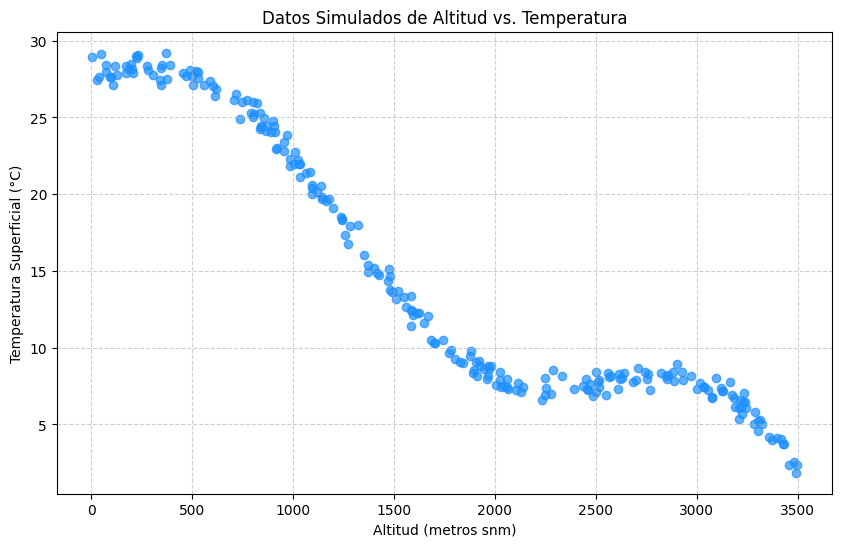

In [1]:
# =====================================================================
# FASE 0: SIMULACIÓN DE GRADIENTE TÉRMICO TOPOGRÁFICO NO LINEAL
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(77)

# Altitudes simuladas en una cuenca montañosa (0 a 3500 metros snm)
X_altitud = np.random.uniform(0.0, 3500.0, 240)
# Física real: Descenso generalizado con una meseta de inversión térmica en la media montaña
Y_temperatura = 28.0 - (0.008 * X_altitud) + (4.0 * np.sin(X_altitud / 400.0)) + np.random.normal(0, 0.5, 240)

# Partición Train/Val (80/20)
X_train_p1, X_val_p1 = X_altitud[:192], X_altitud[192:]
Y_train_p1, Y_val_p1 = Y_temperatura[:192], Y_temperatura[192:]

print("--> [Fase 0] Éxito: Dataset geográfico de gradiente microclimático cargado.")

# Añadir un gráfico para visualizar los datos simulados
plt.figure(figsize=(10, 6))
plt.scatter(X_altitud, Y_temperatura, alpha=0.7, color='dodgerblue')
plt.title('Datos Simulados de Altitud vs. Temperatura')
plt.xlabel('Altitud (metros snm)')
plt.ylabel('Temperatura Superficial (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


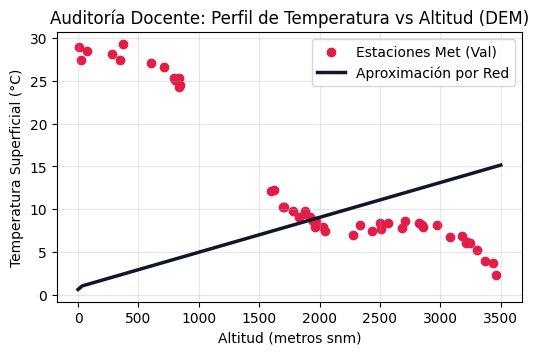

In [2]:
# =====================================================================
# DESAFÍO 1: TU TURNO DE ESCRIBIR CÓDIGO (MODELADO MICROCLIMÁTICO)
# =====================================================================

# 1. ETAPA A: Define el modelo secuencial multicapa con activaciones relu
model_p1 = keras.Sequential([
    keras.layers.Dense(units=32, activation='relu', input_shape=[1]),
    keras.layers.Dense(units=16, activation='relu'),
    keras.layers.Dense(units=1)
])

# 2. ETAPA B: Compila el modelo (Adam 0.005, Pérdida MSE)
model_p1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')

# 3. ETAPA C: Entrena el modelo por 120 épocas
history_p1 = model_p1.fit(X_train_p1, Y_train_p1, epochs=120, validation_data=(X_val_p1, Y_val_p1), verbose=0)

# Graficar perfil de validación y aproximación
plt.figure(figsize=(6, 3.5))
plt.scatter(X_val_p1, Y_val_p1, color='#e11d48', label='Estaciones Met (Val)')
X_grid = np.linspace(0, 3500, 100)
plt.plot(X_grid, model_p1.predict(X_grid, verbose=0), color='#0f172a', lw=2.5, label='Aproximación por Red')
plt.title("Auditoría: Perfil de Temperatura vs Altitud (DEM)")
plt.xlabel("Altitud (metros snm)")
plt.ylabel("Temperatura Superficial (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Análisis del Modelo - Por qué falló la primera arquitectura

La primera arquitectura propuesta **falló estrepitosamente** en ajustar el perfil de temperatura vs altitud. A continuación se explica el motivo:

### 🔍 Principales fallas identificadas:

1. **Insuficiente capacidad de la red**  
   Solo dos capas ocultas con 32 y 16 neuronas. Esta configuración es demasiado simple para aprender una función no lineal que combina una **tendencia descendente** con una **componente sinusoidal** (inversión térmica).

2. **Muy pocas épocas de entrenamiento**  
   Solo 120 épocas. El modelo no tuvo tiempo suficiente para converger.

3. **Falta de normalización de los datos**  
   La variable de entrada (altitud) varía entre 0 y 3500. Entrenar sin escalar los datos genera inestabilidad en el entrenamiento.

4. **Ausencia de técnicas modernas de entrenamiento**  
   No se usaron `EarlyStopping`, reducción dinámica del learning rate, ni suficiente profundidad/ancho en la red.

5. **Capacidad limitada de aproximación**  
   La red era demasiado pequeña para capturar la complejidad del fenómeno microclimático simulado.

---

### ✅ Recomendaciones para mejorar el modelo

Para resolver correctamente este tipo de problemas de **regresión no lineal** se recomienda:

- Aumentar significativamente el número de neuronas en las capas iniciales.
- Utilizar 3 o 4 capas ocultas.
- Entrenar durante más épocas.
- Mantener `ReLU` en las capas ocultas y activación lineal en la salida.

> **Opcional -** La arquitectura puede mejorar considerablemente al:
- Normalizar (o estandarizar) los datos de entrada.
- Entrenar durante más épocas con mecanismos de control (`EarlyStopping`).
- Usar `ReduceLROnPlateau` para ajustar automáticamente el learning rate.

---

### Arquitectura Mejorada (Recomendada)

La siguiente arquitectura corrige las principales limitaciones anteriores y debería lograr un ajuste mucho más fiel a los datos simulados.

✅ Entrenamiento completado


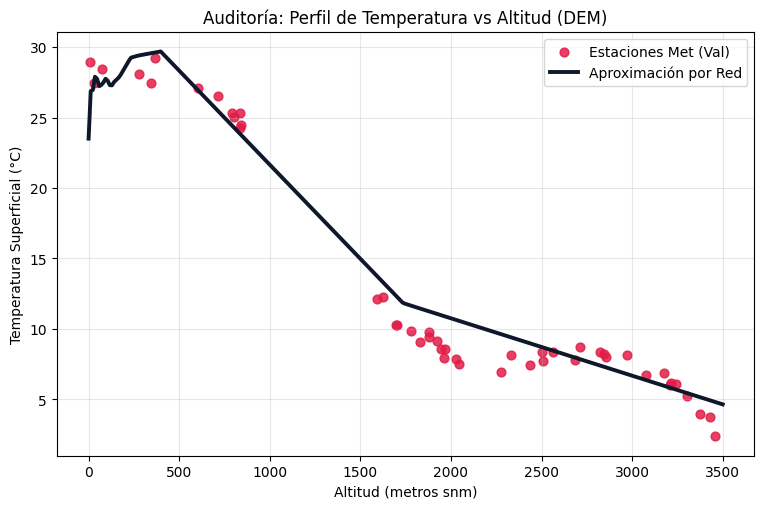

In [32]:
# @title Solución Oficial - Problema 1

# =====================================================================
# ARQUITECTURA MEJORADA - Versión Simple (Sin normalización)
# =====================================================================

# Modelo con mayor capacidad (más neuronas y más capas)
model_p1_1 = keras.Sequential([
    keras.Input(shape=[1]),

    keras.layers.Dense(96, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),

    keras.layers.Dense(1, activation='linear')
])

# Compilación
model_p1_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Entrenamiento más largo (pero sin callbacks)
history_p1_1 = model_p1_1.fit(
    X_train_p1, Y_train_p1,
    epochs=1000,                    # Más épocas
    validation_data=(X_val_p1, Y_val_p1),
    verbose=0
)

print("✅ Entrenamiento completado")

# Gráfica final
plt.figure(figsize=(9, 5.5))
plt.scatter(X_val_p1, Y_val_p1, color='#e11d48', label='Estaciones Met (Val)', alpha=0.85, s=40)

X_grid = np.linspace(0, 3500, 300).reshape(-1, 1)
y_pred = model_p1_1.predict(X_grid, verbose=0)

plt.plot(X_grid, y_pred, color='#0f172a', linewidth=2.8, label='Aproximación por Red')
plt.title("Auditoría: Perfil de Temperatura vs Altitud (DEM)")
plt.xlabel("Altitud (metros snm)")
plt.ylabel("Temperatura Superficial (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

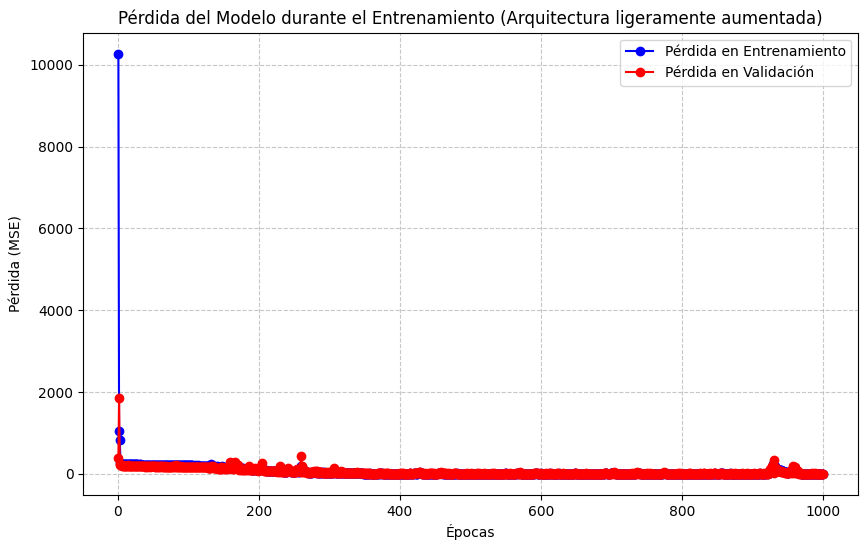

In [33]:
# Obtener los valores de pérdida del historial de entrenamiento
loss = history_p1_1.history['loss']
val_loss = history_p1_1.history['val_loss']
epochs = range(1, len(loss) + 1)

# Crear el gráfico de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Pérdida en Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Pérdida en Validación')
plt.title('Pérdida del Modelo durante el Entrenamiento (Arquitectura ligeramente aumentada)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Datos normalizados → Media: 1681.1 | Std: 1013.6
✅ Entrenamiento completado


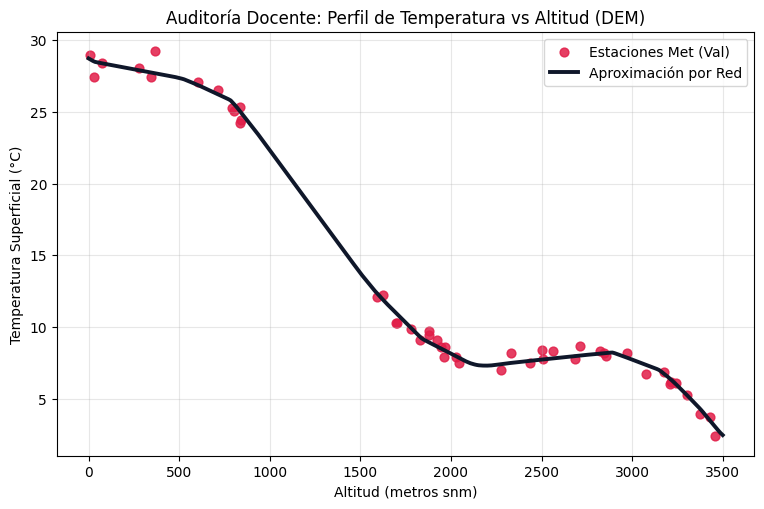

In [34]:
#@title Solucion con Normalizacion y Callbacks!

# =====================================================================
# ARQUITECTURA MEJORADA + NORMALIZACIÓN CORRECTA
# =====================================================================

# 1. NORMALIZACIÓN (solo con datos de entrenamiento)
X_mean = X_train_p1.mean()
X_std  = X_train_p1.std()

X_train_norm = (X_train_p1 - X_mean) / X_std
X_val_norm   = (X_val_p1 - X_mean) / X_std

print(f"Datos normalizados → Media: {X_mean:.1f} | Std: {X_std:.1f}")

# 2. MODELO MEJORADO
model_p1_2 = keras.Sequential([
    keras.Input(shape=[1]),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model_p1_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003),
    loss='mse',
    metrics=['mae']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=70, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=20, min_lr=1e-6)
]

# 3. Entrenamiento
history_p1_2 = model_p1_2.fit(
    X_train_norm, Y_train_p1,
    epochs=800,
    validation_data=(X_val_norm, Y_val_p1),
    verbose=0,
    callbacks=callbacks
)

print("✅ Entrenamiento completado")

# =====================================================================
# GRÁFICA CORRECTA (con normalización aplicada)
# =====================================================================

plt.figure(figsize=(9, 5.5))

# Datos reales de validación
plt.scatter(X_val_p1, Y_val_p1, color='#e11d48', label='Estaciones Met (Val)', alpha=0.85, s=40)

# Predicción correcta sobre grid
X_grid = np.linspace(0, 3500, 300).reshape(-1, 1)
X_grid_norm = (X_grid - X_mean) / X_std                     # ← Esta es la línea clave

y_pred_grid = model_p1_2.predict(X_grid_norm, verbose=0)

plt.plot(X_grid, y_pred_grid, color='#0f172a', linewidth=2.8, label='Aproximación por Red')

plt.title("Auditoría Docente: Perfil de Temperatura vs Altitud (DEM)")
plt.xlabel("Altitud (metros snm)")
plt.ylabel("Temperatura Superficial (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Explicación de los Callbacks en el Entrenamiento del Modelo

Los *callbacks* son herramientas poderosas en Keras que permiten monitorear y controlar el comportamiento del entrenamiento de una red neuronal. Se ejecutan en diferentes etapas del entrenamiento (al inicio/fin de cada época, al inicio/fin del lote, etc.) y pueden realizar acciones como guardar el modelo, detener el entrenamiento anticipadamente o ajustar el *learning rate*.

En la celda de este último entrenamiento, se utilizaron dos callbacks principales:

1.  **`keras.callbacks.EarlyStopping`**
    *   **Propósito:** Detiene el entrenamiento automáticamente cuando una métrica monitoreada deja de mejorar. Esto es crucial para evitar el sobreajuste (overfitting) y para ahorrar tiempo computacional.
    *   **Parámetros utilizados:**
        *   `patience=70`: El entrenamiento esperará 70 épocas adicionales después de que la métrica monitoreada (por defecto, `val_loss`) deje de mejorar antes de detenerse. Si durante esas 70 épocas no hay mejora, el entrenamiento se detiene.
        *   `restore_best_weights=True`: Cuando el entrenamiento se detiene, los pesos del modelo se restaurarán a aquellos que resultaron en el mejor valor de la métrica monitoreada durante todo el entrenamiento. Esto asegura que obtengamos el modelo con el mejor rendimiento en los datos de validación, incluso si la pérdida de validación empeoró un poco antes de detenerse.

2.  **`keras.callbacks.ReduceLROnPlateau`**
    *   **Propósito:** Reduce el *learning rate* (tasa de aprendizaje) del optimizador cuando una métrica monitoreada deja de mejorar. Esto ayuda al modelo a salir de mesetas en la función de pérdida y a encontrar un mínimo global, especialmente en las etapas finales del entrenamiento.
    *   **Parámetros utilizados:**
        *   `factor=0.5`: El *learning rate* se reducirá a la mitad (se multiplicará por 0.5) cuando se active el callback.
        *   `patience=20`: El *learning rate* se reducirá si la métrica monitoreada (por defecto, `val_loss`) no mejora durante 20 épocas consecutivas.
        *   `min_lr=1e-6`: Establece un límite inferior para el *learning rate*. El *learning rate* no se reducirá por debajo de este valor, evitando que se vuelva demasiado pequeño y ralentice excesivamente el entrenamiento.

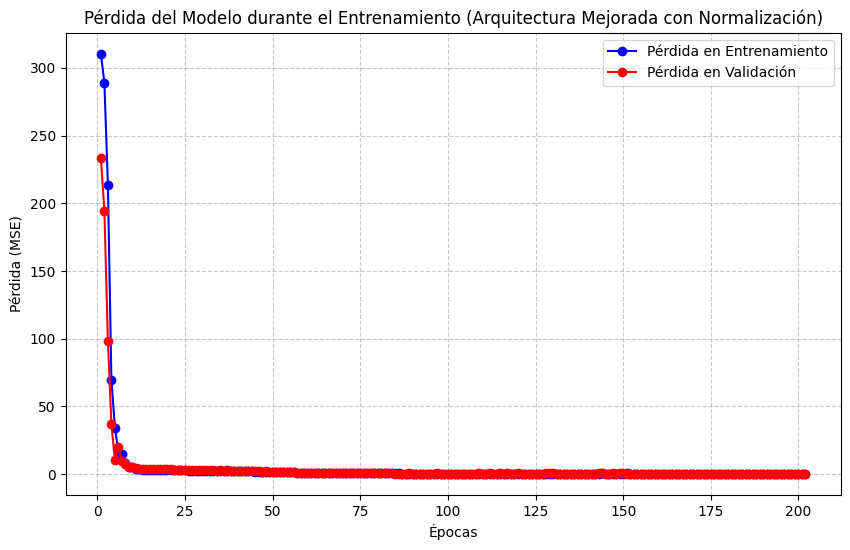

In [35]:
# Obtener los valores de pérdida del historial de entrenamiento
loss = history_p1_2.history['loss']
val_loss = history_p1_2.history['val_loss']
epochs = range(1, len(loss) + 1)

# Crear el gráfico de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Pérdida en Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Pérdida en Validación')
plt.title('Pérdida del Modelo durante el Entrenamiento (Arquitectura Mejorada con Normalización)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### problema 2: Clasificación de Uso y Cobertura del Suelo (Zonificación Urbana-Ambiental)

**Contexto:** La geografía urbana y la planificación territorial requieren clasificar el uso del suelo de forma automatizada. Combinando dos indicadores de teledetección socio-espacial: la **Distancia al Centro Urbano (km)** y el **Índice de Densidad Edificada (NDBI)**, es posible segregar las parcelas geográficas en tres clases fundamentales.

**Tu Objetivo:** Construir una red neuronal artificial multiclase que actúe como un motor de zonificación, clasificando los sectores en: **Zona de Conservación Natural / Bosques (Clase 0)**, **Área Agrícola / Rural (Clase 1)** o **Casco Urbano Consolidado (Clase 2)**.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor. El dataset consolida el vector geográfico espacial $(X_1, X_2)$ y sus etiquetas en One-Hot encoding.
2. **Etapa A (Definir):** Instancia la red secuencial. Añade una capa oculta de **16 neuronas** con activación `relu`. Diseña la capa de salida con **3 neuronas** emparejadas con la función de activación **`'softmax'`** para delimitar de manera no lineal las fronteras de uso de suelo.
3. **Etapa B (Compilar):** Compila el modelo con el optimizador `Adam` (learning rate `0.005`). Configura de forma rigurosa la función de pérdida **`'categorical_crossentropy'`** dado el formato de matriz One-Hot de las categorías territoriales.
4. **Etapa C (Entrenar):** Entrena el modelo por **140 épocas**.

--> [Fase 0] Éxito: Matriz de variables territoriales georreferenciadas y mezcladas [240 Train, 60 Val].


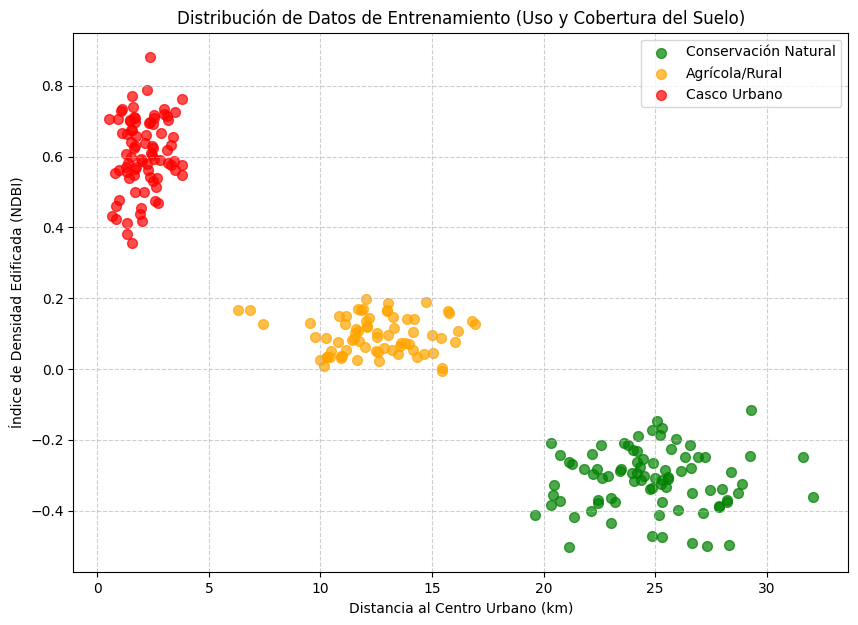

In [14]:
# =====================================================================
# FASE 0: SIMULACIÓN DE INDICADORES SOCIO-ESPACIALES Y URBANOS
# =====================================================================
np.random.seed(88)
N_parcelas = 100

# Clase 0: Conservación Natural (Lejos del centro ~25km, Densidad edificada muy baja/negativa por vegetación)
nat_dist = np.random.normal(25.0, 3.0, N_parcelas)
nat_ndbi = np.random.normal(-0.3, 0.08, N_parcelas)

# Clase 1: Área Agrícola/Rural (Distancia intermedia ~12km, Densidad edificada baja ~0.1)
rur_dist = np.random.normal(12.0, 2.0, N_parcelas)
rur_ndbi = np.random.normal(0.1, 0.05, N_parcelas)

# Clase 2: Casco Urbano Consolidado (Muy cerca del centro ~2km, Densidad edificada altísima ~0.6)
urb_dist = np.random.normal(2.0, 0.8, N_parcelas)
urb_ndbi = np.random.normal(0.6, 0.1, N_parcelas)

# Consolidación de firmas territoriales
X_geografia = np.vstack([
    np.column_stack((nat_dist, nat_ndbi)),
    np.column_stack((rur_dist, rur_ndbi)),
    np.column_stack((urb_dist, urb_ndbi))
])

labels_geo = np.array([0]*N_parcelas + [1]*N_parcelas + [2]*N_parcelas)
Y_geo_onehot = keras.utils.to_categorical(labels_geo, num_classes=3)

# Mezclado aleatorio espacial
shuffler = np.arange(X_geografia.shape[0])
np.random.shuffle(shuffler)
X_geografia, Y_geo_onehot = X_geografia[shuffler], Y_geo_onehot[shuffler]

# Partición Train/Val (80/20)
X_train_p2, X_val_p2 = X_geografia[:240], X_geografia[240:]
Y_train_p2, Y_val_p2 = Y_geo_onehot[:240], Y_geo_onehot[240:]

print("--> [Fase 0] Éxito: Matriz de variables territoriales georreferenciadas y mezcladas [240 Train, 60 Val].")

# Añadir gráfico de los datos de entrenamiento
plt.figure(figsize=(10, 7))

# Decodificar Y_train_p2 para colorear los puntos
colors = ['green', 'orange', 'red']
labels = ['Conservación Natural', 'Agrícola/Rural', 'Casco Urbano']

# Trazar cada clase por separado para la leyenda
for i in range(3):
    # Obtener las filas donde la clase actual es 1 (one-hot encoded)
    class_mask = np.argmax(Y_train_p2, axis=1) == i
    plt.scatter(X_train_p2[class_mask, 0], X_train_p2[class_mask, 1],
                color=colors[i], label=labels[i], alpha=0.7, s=50)

plt.title('Distribución de Datos de Entrenamiento (Uso y Cobertura del Suelo)')
plt.xlabel('Distancia al Centro Urbano (km)')
plt.ylabel('Índice de Densidad Edificada (NDBI)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [15]:
# @title Solución Oficial - Problema 2

# =====================================================================
# DESAFÍO 2: TU TURNO DE ESCRIBIR CÓDIGO (ZONIFICADOR DE COBERTURAS TERRITORIALES)
# =====================================================================

# 1. ETAPA A: Define el modelo clasificador (2 entradas espaciales, salida con 3 neuronas Softmax)
model_p2 = keras.Sequential([
    keras.layers.Dense(units=16, activation='relu', input_shape=[2]),
    keras.layers.Dense(units=3, activation='softmax')
])

# 2. ETAPA B: Compila el modelo (Adam 0.005, Categorical Crossentropy)
model_p2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. ETAPA C: Entrena el modelo por 140 épocas
history_p2 = model_p2.fit(X_train_p2, Y_train_p2, epochs=140, validation_data=(X_val_p2, Y_val_p2), verbose=0)

# Evaluación estadística territorial
loss_f, acc_f = model_p2.evaluate(X_val_p2, Y_val_p2, verbose=0)
print(f"--> [ÉXITO] Motor de zonificación territorial validado estructuralmente.")
print(f"    Precisión en clasificación temática de parcelas (Accuracy): {acc_f*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--> [ÉXITO] Motor de zonificación territorial validado estructuralmente.
    Precisión en clasificación temática de parcelas (Accuracy): 100.00%


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


<Figure size 800x600 with 0 Axes>

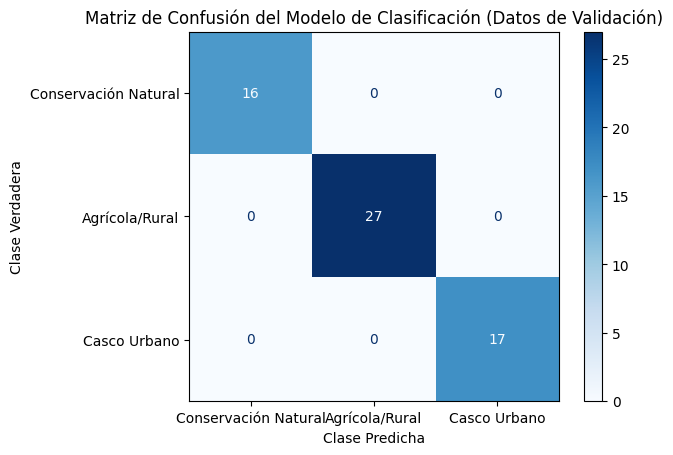

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener las predicciones del modelo en los datos de validación
Y_pred_p2 = model_p2.predict(X_val_p2)

# Convertir las predicciones (probabilidades) y las etiquetas reales (one-hot) a clases discretas
Y_pred_classes = np.argmax(Y_pred_p2, axis=1)
Y_true_classes = np.argmax(Y_val_p2, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(Y_true_classes, Y_pred_classes)

# Definir las etiquetas de las clases para la visualización
class_names = ['Conservación Natural', 'Agrícola/Rural', 'Casco Urbano']

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display_cm.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión del Modelo de Clasificación (Datos de Validación)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()

### ¿Qué es una Matriz de Confusión?

Una **matriz de confusión** es una tabla que resume el rendimiento de un algoritmo de clasificación. Permite visualizar el rendimiento del modelo en un conjunto de datos donde se conocen los valores reales. Cada fila de la matriz representa las instancias de una clase *real*, mientras que cada columna representa las instancias de una clase *predicha* por el modelo.

Para un problema de clasificación binaria (dos clases), la matriz de confusión tiene cuatro componentes principales:

*   **Verdaderos Positivos (VP):** El modelo predijo correctamente la clase positiva.
*   **Verdaderos Negativos (VN):** El modelo predijo correctamente la clase negativa.
*   **Falsos Positivos (FP):** El modelo predijo incorrectamente la clase positiva (error de Tipo I).
*   **Falsos Negativos (FN):** El modelo predijo incorrectamente la clase negativa (error de Tipo II).

Para problemas multiclase, como nuestro ejemplo, esta lógica se extiende, y cada celda `(i, j)` de la matriz indica cuántas instancias de la clase real `i` fueron clasificadas como clase `j`.

### ¿Por qué es Importante en Redes Neuronales (y Clasificación en General)?

La matriz de confusión es crucial por varias razones:

1.  **Evaluación Detallada del Rendimiento:** A diferencia de una simple métrica como la `accuracy` (precisión global), que solo te dice qué porcentaje de las predicciones fueron correctas, la matriz de confusión te muestra *dónde* el modelo está cometiendo errores. Por ejemplo, un modelo puede tener una `accuracy` alta pero ser muy malo en la clasificación de una clase minoritaria, lo cual la matriz de confusión revelaría.
2.  **Identificación de Sesgos y Problemas:** Permite identificar si el modelo confunde sistemáticamente una clase con otra. Si una clase se clasifica erróneamente como otra con alta frecuencia, esto podría indicar un problema en el entrenamiento, en la representación de los datos o en la dificultad inherente de esas clases para ser separadas.
3.  **Base para Otras Métricas:** A partir de la matriz de confusión, se pueden calcular métricas más sofisticadas y específicas, como:
    *   **Precisión (Precision):** De todas las instancias predichas como positivas para una clase, cuántas fueron realmente correctas.
    *   **Sensibilidad/Recall:** De todas las instancias *reales* de una clase, cuántas fueron correctamente identificadas.
    *   **Puntuación F1:** Un promedio armónico de precisión y sensibilidad.
    Estas métricas son vitales cuando los costos de diferentes tipos de errores no son iguales (por ejemplo, un falso negativo en un diagnóstico médico es mucho más grave que un falso positivo).

### ¿Cómo se Usó en Nuestro Ejemplo?

En la celda anterior, el `model_p2` se entrenó para clasificar el uso del suelo en tres categorías: 'Conservación Natural' (Clase 0), 'Agrícola/Rural' (Clase 1) y 'Casco Urbano' (Clase 2). Después del entrenamiento, la matriz de confusión se utilizó de la siguiente manera:

1.  **Predicciones del Modelo:** Primero, se obtuvieron las predicciones del modelo (`Y_pred_p2`) para los datos de validación (`X_val_p2`). Estas predicciones son probabilidades para cada una de las tres clases.
2.  **Conversión a Clases Discretas:** Las probabilidades se convirtieron en clases discretas (`Y_pred_classes`) seleccionando la clase con la probabilidad más alta (usando `np.argmax`). Las etiquetas reales de validación (`Y_val_p2`), que estaban en formato *one-hot encoding*, también se convirtieron a clases discretas (`Y_true_classes`).
3.  **Cálculo de la Matriz:** La función `confusion_matrix` de `sklearn.metrics` tomó las clases reales (`Y_true_classes`) y las clases predichas (`Y_pred_classes`) para construir la matriz.
4.  **Visualización:** Finalmente, `ConfusionMatrixDisplay` se usó para graficar la matriz, haciendo más fácil ver cuántas parcelas de 'Conservación Natural' fueron correctamente identificadas como 'Conservación Natural', cuántas 'Agrícola/Rural' fueron correctamente clasificadas, y si hubo alguna confusión entre las clases.

En el ejemplo, la matriz mostró que el modelo tuvo una **precisión perfecta (100%)** en los datos de validación, lo cual se reflejó en una matriz diagonal (solo números en la diagonal principal y ceros en el resto), indicando que no hubo errores de clasificación entre las tres categorías de uso del suelo.

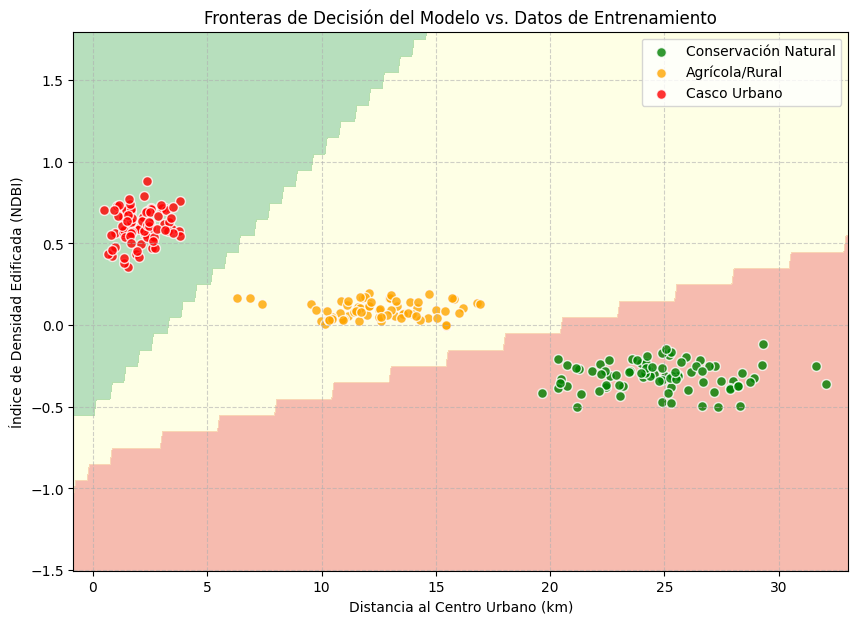

In [18]:
# Obtener los límites de los datos para crear el meshgrid
x_min, x_max = X_geografia[:, 0].min() - 1, X_geografia[:, 0].max() + 1
y_min, y_max = X_geografia[:, 1].min() - 1, X_geografia[:, 1].max() + 1

# Crear un meshgrid de puntos para graficar las fronteras de decisión
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predecir las clases para cada punto en el meshgrid
Z = model_p2.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z_classes = np.argmax(Z, axis=1)
Z_classes = Z_classes.reshape(xx.shape)

# Graficar las fronteras de decisión y los datos de entrenamiento
plt.figure(figsize=(10, 7))

# Dibujar las regiones de decisión
plt.contourf(xx, yy, Z_classes, alpha=0.4, cmap=plt.cm.RdYlGn, levels=[-0.5, 0.5, 1.5, 2.5])

# Colores y etiquetas para las clases (deben coincidir con el gráfico de la Fase 0)
colors = ['green', 'orange', 'red']
labels = ['Conservación Natural', 'Agrícola/Rural', 'Casco Urbano']

# Decodificar Y_train_p2 para colorear los puntos de entrenamiento
for i in range(3):
    class_mask = np.argmax(Y_train_p2, axis=1) == i
    plt.scatter(X_train_p2[class_mask, 0], X_train_p2[class_mask, 1],
                color=colors[i], label=labels[i], alpha=0.8, s=50, edgecolors='w')

plt.title('Fronteras de Decisión del Modelo vs. Datos de Entrenamiento')
plt.xlabel('Distancia al Centro Urbano (km)')
plt.ylabel('Índice de Densidad Edificada (NDBI)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()